## Answer
 
The classification task is not trivial to classify because it contains a wide 
variety of images of cats and dogs. The images in the dataset have differences in resolution, 
background complexity, lighting conditions, and variation in breeds and poses. Some images have 
simple backgrounds while others have many objects, which can make it harder for the model to focus 
on the animal. The lighting and image quality also change from image to image. In addition, cats and 
dogs can sometimes look similar depending on the angle or pose. Because of these variations, it becomes 
more difficult for the model to correctly classify the images.

Normalization and dataset splitting are important for stable and fair training. Normalization scales 
the pixel values to a smaller range, usually between 0 and 1. This helps the model learn more efficiently 
and makes the training process more stable because very large values can slow down learning or cause unstable 
updates.

Dataset splitting is also necessary because it allows the model to be evaluated on data it has not seen 
during training. The training set is used to learn patterns, while the validation set is used to check 
how well the model generalizes to new data. This helps detect overfitting and gives a more fair evaluation 
of the model’s performance.

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Rescaling
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

import os
from PIL import Image
import matplotlib.image as mpimg


# Visualization

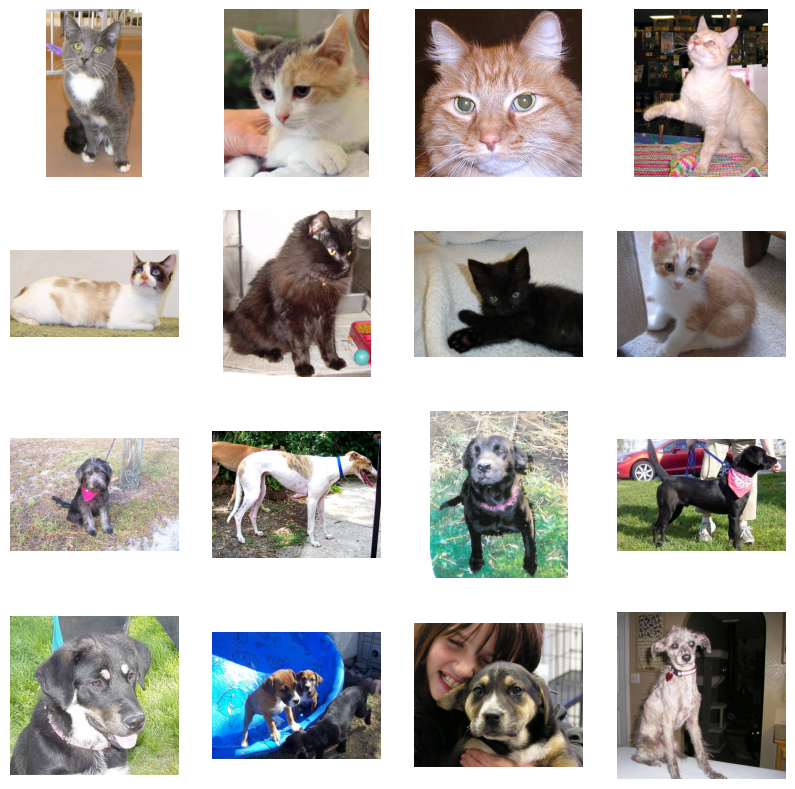

In [2]:
fig = plt.gcf() # Get current figure
fig.set_size_inches(10, 10) # Set figure size to 10x10 inches

cat_dir = os.path.join('cat') # Create path to cat directory
dog_dir = os.path.join('dog') # Create path to dog directory

cat_names = os.listdir(cat_dir) # List all files in cat directory and store in cat_names
dog_names = os.listdir(dog_dir) # List all files in dog directory and store in dog_names    

pic_index = 210 # Set the index of the picture to be displayed

cat_images = [os.path.join(cat_dir, fname) 
              for fname in cat_names[pic_index-8:pic_index]] # select cat images based on the index

dog_images = [os.path.join(dog_dir, fname)
              for fname in dog_names[pic_index-8:pic_index]] # select dog images based on the index

for i, img_path in enumerate(cat_images + dog_images): # Loop through the selected cat and dog images
    sp = plt.subplot(4, 4, i + 1)  # creates a 4x4 grid for images.
    sp.axis('Off')  # Hide axes for better visualization
    img = mpimg.imread(img_path) # Read the image from the file path and store it in img variable
    plt.imshow(img) # Display the image in the current subplot

plt.show() # Display the images in a 4x4 grid

# Data Preprocessing

### Remove invalid channels

In [3]:
import os
from PIL import Image

base_path = "."

corrupted_files = []
total_checked = 0

for class_name in ["cat", "dog"]:
    class_path = os.path.join(base_path, class_name)

    for filename in os.listdir(class_path):
        file_path = os.path.join(class_path, filename)
        total_checked += 1

        try:
            img = Image.open(file_path)
            img.verify()

            if img.format.lower() not in ["jpg", "jpeg", "png",]:
                corrupted_files.append(file_path)

        except Exception:
            corrupted_files.append(file_path)

# Delete corrupted files
for file in corrupted_files:
    os.remove(file)
    print(f"Deleted: {file}")

print("\nFinished cleaning dataset.")
print(f"Total images checked: {total_checked}")
print(f"Corrupted images removed: {len(corrupted_files)}")


Finished cleaning dataset.
Total images checked: 24828
Corrupted images removed: 0



### Splitting dataset

In [4]:
base_dir = '.'

train_datagen = image_dataset_from_directory(
    base_dir,
    image_size=(200, 200),
    subset='training',
    seed=1,
    validation_split=0.1,
    batch_size=32
)

test_datagen = image_dataset_from_directory(
    base_dir,
    image_size=(200, 200),
    subset='validation',
    seed=1,
    validation_split=0.1,
    batch_size=32
)

Found 24859 files belonging to 3 classes.
Using 22374 files for training.
Found 24859 files belonging to 3 classes.
Using 2485 files for validation.


### Normalization

In [5]:
normalization_layer = Rescaling(1./255)
normalized_train_ds = train_datagen.map(lambda x, y: (normalization_layer(x), y))
normalized_test_ds = test_datagen.map(lambda x, y: (normalization_layer(x), y))

### Model Building

In [6]:
model = Sequential([

    # Extract image features like edges, shapes and textures
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(2, 2), # Reduces image dimensions while retaining important information

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation='relu'), # Fully connected layer to learn complex patterns in the data.
    Dropout(0.1), # Randomly drops 10% of the neurons during training to prevent overfitting.
    BatchNormalization(), # helps stabilize training and speed up convergence.

    Dense(512, activation='relu'),
    Dropout(0.1),
    BatchNormalization(),

    Dense(512, activation='relu'), # 
    Dropout(0.2), # prevent overfitting.
    BatchNormalization(),

    Dense(1, activation='sigmoid') # outputs a binary classification as Cat or Dog.
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

# Answer

he CNN architecture uses multiple convolutional layers followed by pooling layers to extract features from 
the images. The convolutional layers, such as `Conv2D(32, (3,3), activation='relu')` and `Conv2D(64, (3,3), 
activation='relu')`, detect visual patterns like edges, shapes, and textures. After each convolutional layer, 
a `MaxPooling2D(2,2)` layer reduces the spatial size of the feature maps, which lowers computation and keeps 
the most important information.

The number of filters increases as the network gets deeper, starting with 32 filters and then using 64 filters. 
This allows the model to learn more complex visual features at deeper layers.

After feature extraction, the `Flatten()` layer converts the feature maps into a one-dimensional vector so the 
data can be used by fully connected layers. The dense layers, such as `Dense(512, activation='relu')`, combine 
the learned features and help the model perform classification.

Regularization techniques are also included. `BatchNormalization()` stabilizes the training process, and `Dropout()` 
helps reduce overfitting by randomly disabling some neurons during training.

Finally, the last layer `Dense(1, activation='sigmoid')` outputs a single probability value. The sigmoid activation 
function is used because the task is binary classification between cats and dogs.

###  Model Compilation and Training

In [7]:
# Compile the model with binary crossentropy loss, Adam optimizer, and accuracy metric
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the model for 10 epochs using the training data and validate on the test data
history = model.fit(
    normalized_train_ds,
    epochs=10,
    validation_data=normalized_test_ds
)

Epoch 1/10
 49/700 ━━━━━━━━━━━━━━━━━━━━ 4:22 403ms/step - accuracy: 0.5526 - loss: 0.9346

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


175/700 ━━━━━━━━━━━━━━━━━━━━ 3:42 424ms/step - accuracy: 0.5519 - loss: 0.8723

195/700 ━━━━━━━━━━━━━━━━━━━━ 3:32 420ms/step - accuracy: 0.5513 - loss: 0.8657

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


...

628/700 ━━━━━━━━━━━━━━━━━━━━ 2:16 2s/step - accuracy: 0.9335 - loss: 0.1315

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9336 - loss: 0.1297

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


700/700 ━━━━━━━━━━━━━━━━━━━━ 1228s 2s/step - accuracy: 0.9319 - loss: 0.1190 - val_accuracy: 0.8604 - val_loss: 0.4881


### Model Evaluation

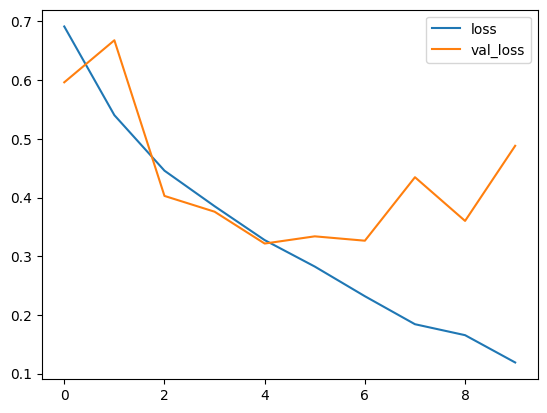

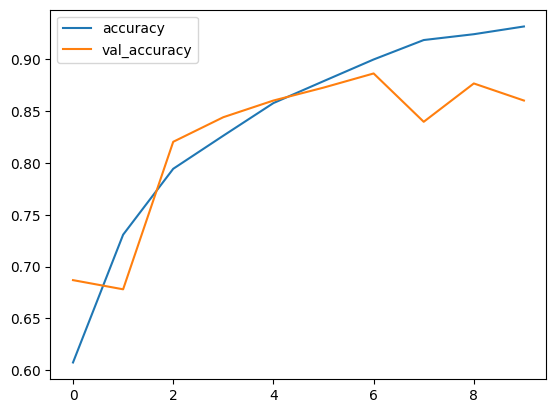

In [8]:
history_df = pd.DataFrame(history.history)

history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()

plt.show()

# Answer

The model was compiled using binary cross-entropy loss, the Adam optimizer, and accuracy as the evaluation metric. The model was trained for 10 epochs while tracking both training and validation accuracy and loss.

From the training results, the model gradually improved during the epochs. The training accuracy increased from around 60% in the first epoch to about 93% by the final epoch. The validation accuracy also improved and reached around 86–88% during training.

## Analyze the learning curves

The learning curves indicate that the model is learning meaningful features from the images. The training accuracy increases steadily during the epochs and reaches about 93% by the final epoch. The validation accuracy also improves during the first epochs and reaches its highest value of about 0.8865 in epoch 7.

However, after epoch 7 the validation accuracy slightly decreases and reaches about 0.86 in epoch 10, while the training accuracy continues to increase. This indicates that the model starts to show signs of overfitting.




## Evaluate the model on the validation dataset

In [9]:
loss, accuracy = model.evaluate(normalized_test_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

19/78 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.8654 - loss: 0.3864

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


58/78 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.8620 - loss: 0.3875

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.8604 - loss: 0.4881
Validation Loss: 0.48807036876678467
Validation Accuracy: 0.86036217212677


## Inspect several predictions


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


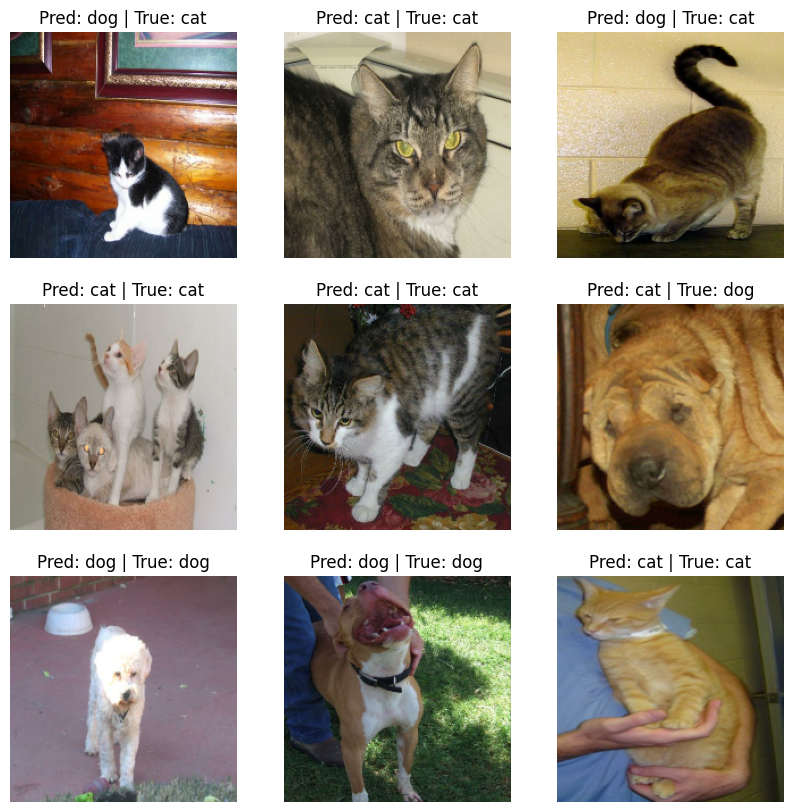

2026-03-09 02:08:18.906933: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
class_names = ["cat", "dog"]

for images, labels in normalized_test_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(10,10))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow((images[i].numpy() * 255).astype("uint8"))

        pred = 1 if predictions[i] > 0.5 else 0
        true = labels[i]

        title = f"Pred: {class_names[pred]} | True: {class_names[int(true)]}"
        plt.title(title)

        plt.axis("off")

    plt.show()

## Evaluation of the model and inspection of predictions

The model achieved around 86% accuracy on the validation set, which indicates that the model is able to correctly classify most images of cats and dogs. 

However, some images were misclassified. For instance, in one case a dog was predicted as a cat, and in another case a cat was predicted as a dog. These misclassifications may occur for several reasons. Some images were misclassified due to visual ambiguity and background noise. For example, a dog with unusual facial features and wrinkles was predicted as a cat because its appearance differs from typical dog shapes in the dataset. In another case, a cat was predicted as a dog because the animal occupied a small part of the image and the background contained strong visual patterns that may have distracted the model. These examples show how pose, lighting, and background complexity can affect CNN predictions.

# Add data augmentation

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.3)
])


In [16]:
model_aug = Sequential([

    data_augmentation,

      # Extract image features like edges, shapes and textures
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(2, 2), # Reduces image dimensions while retaining important information

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation='relu'), # Fully connected layer to learn complex patterns in the data.
    Dropout(0.1), # Randomly drops 10% of the neurons during training to prevent overfitting.
    BatchNormalization(), # helps stabilize training and speed up convergence.

    Dense(512, activation='relu'),
    Dropout(0.1),
    BatchNormalization(),

    Dense(512, activation='relu'), # 
    Dropout(0.2), # prevent overfitting.
    BatchNormalization(),

    Dense(1, activation='sigmoid') # outputs a binary classification as Cat or Dog.
])

In [17]:
model_aug.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [18]:
history_aug = model_aug.fit(
    normalized_train_ds,
    epochs=10,
    validation_data=normalized_test_ds
)

Epoch 1/10
 46/700 ━━━━━━━━━━━━━━━━━━━━ 5:20 490ms/step - accuracy: 0.5123 - loss: 0.9383

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


170/700 ━━━━━━━━━━━━━━━━━━━━ 4:28 506ms/step - accuracy: 0.5175 - loss: 0.8902

178/700 ━━━━━━━━━━━━━━━━━━━━ 4:24 507ms/step - accuracy: 0.5182 - loss: 0.8873

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


...

632/700 ━━━━━━━━━━━━━━━━━━━━ 47s 705ms/step - accuracy: 0.8579 - loss: 0.3296

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.8582 - loss: 0.3287

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


700/700 ━━━━━━━━━━━━━━━━━━━━ 514s 734ms/step - accuracy: 0.8611 - loss: 0.3197 - val_accuracy: 0.8732 - val_loss: 0.2915


## Observation

After applying data augmentation, the training accuracy decreased to around 86%, while the validation accuracy remained around 87%. This occurs because augmented images introduce additional variability during training, making the learning task more challenging. However, the similar validation accuracy indicates that the model generalizes better and is less likely to overfit the training data. Data augmentation therefore helps improve robustness by exposing the model to more diverse image variations.